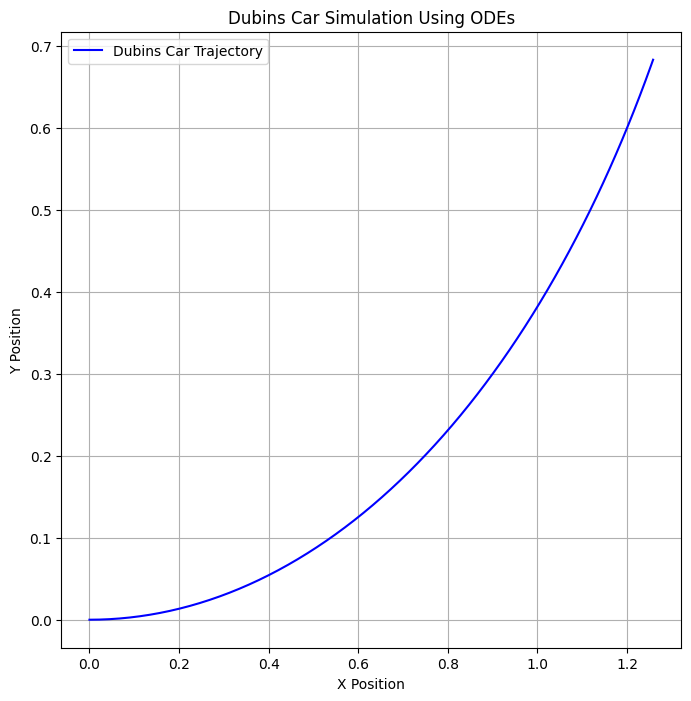

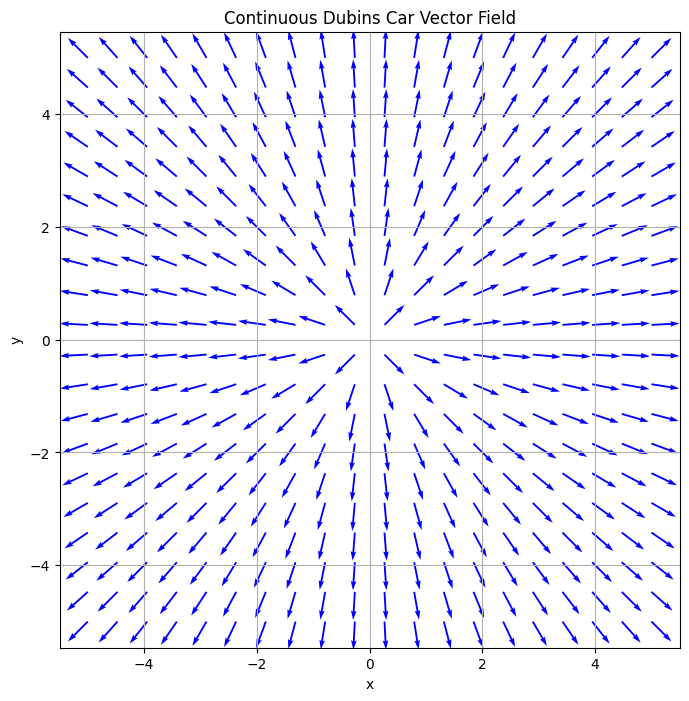

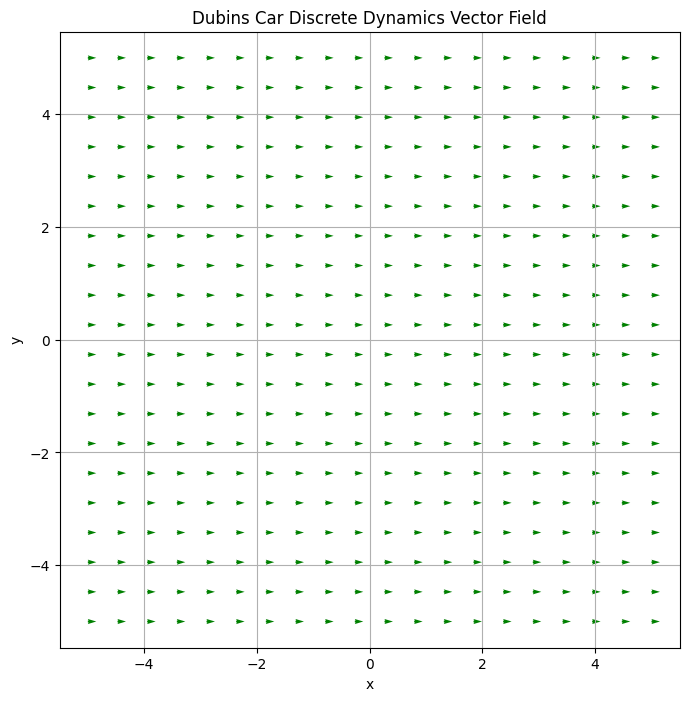

In [1]:
import torch
import discretize_distributions as dd

import discretize_distributions.schemes as dd_schemes
import discretize_distributions.distributions as dd_dists
import discretize_distributions.optimal as dd_optimal

from matplotlib import pyplot as plt
import numpy as np
from dynamics import DubinsCar
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from dubins_plotting import dubins_car_ode

In [14]:
# settings
dt = 2
T = 10
v = 3
num_locs = 100
dubins_car = DubinsCar(v=v, dt=dt)

loc = torch.tensor([0.0, 0.0, 0.0])
covariance_matrix = torch.diag_embed(torch.tensor([[1.0, 1.0, 1.0]]))
component_distribution = dd_dists.MultivariateNormal(loc=loc, covariance_matrix=covariance_matrix)
mixture_distribution = torch.distributions.Categorical(probs=torch.tensor([1,]))

x_0 = dd_dists.MixtureMultivariateNormal(mixture_distribution, component_distribution)

centers, clusters = dd_optimal.dbscan_clusters(gmm=x_0)
mix_grid0 = dd_optimal.create_grid_from_clusters(x_0, centers, clusters, num_locs=num_locs)
disc0, _ = dd.discretize(x_0, mix_grid0)

x_k = disc0

theta0 = 0.0
omega = 0.1
u = torch.tensor([omega])
num_particles = x_k.locs.shape[0]
timesteps = int(T/dubins_car.dt)  # or int(T / dt) if you're using `T` and `dt`
trajectories = []

# emp approx
M = 500
empirical_samples = x_0.sample((M,))
empirical_trajectories = []
empirical_state = empirical_samples  # (M, 3)

Requested grid size: 100, realized grid size over domain: 100
Signature w2: 1.7321 / 1.7321 for grid of size: 1
w2 for whole space to z: 1.7320507764816284
Signature w2: 0.5496 / 1.7321 for grid of size: 100
w2 for grid 0: 0.5495668649673462
Signature w2: 1.7321 / 1.7321 for grid of size: 1
w2 for grid 0 to z: 1.7320507764816284


In [15]:
for k in range(timesteps):
    trajectories.append(x_k.locs.detach().clone())
    empirical_trajectories.append(empirical_state.detach().clone())
    # dynamics using signature
    u_batched = u.repeat(len(x_k.locs), 1)
    x_next = dubins_car.rk4_step(x_k.locs, u, dubins_car.dt)  # no noise

    # emp approx dynamics
    u_emp = u.repeat(empirical_state.shape[0], 1)
    empirical_state = dubins_car.rk4_step(empirical_state, u_emp, dubins_car.dt)

    # locs are the propagated locs from previous step, prob mass from previous step, cov stays same due to
    # additive noise! prove later
    component_distribution = dd_dists.MultivariateNormal(loc=x_next, covariance_matrix=covariance_matrix)
    mixture_distribution = torch.distributions.Categorical(probs=x_k.probs)
    dist = dd_dists.MixtureMultivariateNormal(mixture_distribution, component_distribution)

    # discretize again
    centers, clusters = dd_optimal.dbscan_clusters(gmm=dist)
    mix_grid = dd_optimal.create_grid_from_clusters(dist, centers, clusters, num_locs=num_locs)
    disc, _ = dd.discretize(dist, mix_grid)
    x_k = disc

Requested grid size: 100, realized grid size over domain: 100
Signature w2: 8.4960 / 1.7321 for grid of size: 1
Signature w2: 8.1713 / 1.7321 for grid of size: 1
Signature w2: 7.9668 / 1.7321 for grid of size: 1
Signature w2: 7.8146 / 1.7321 for grid of size: 1
Signature w2: 7.7022 / 1.7321 for grid of size: 1
Signature w2: 4.6640 / 1.7321 for grid of size: 1
Signature w2: 4.7485 / 1.7321 for grid of size: 1
Signature w2: 4.9187 / 1.7321 for grid of size: 1
Signature w2: 5.1707 / 1.7321 for grid of size: 1
Signature w2: 5.5855 / 1.7321 for grid of size: 1
Signature w2: 1.8911 / 1.7321 for grid of size: 1
Signature w2: 2.2970 / 1.7321 for grid of size: 1
Signature w2: 2.7645 / 1.7321 for grid of size: 1
Signature w2: 3.3025 / 1.7321 for grid of size: 1
Signature w2: 4.0340 / 1.7321 for grid of size: 1
Signature w2: 3.6848 / 1.7321 for grid of size: 1
Signature w2: 3.4754 / 1.7321 for grid of size: 1
Signature w2: 3.4490 / 1.7321 for grid of size: 1
Signature w2: 3.5512 / 1.7321 for grid

In [16]:
x0, y0, theta0 = 0.0, 0.0, 0.0
state0 = [x0, y0, theta0]
t_eval = np.arange(0, T, dt)
solution = solve_ivp(dubins_car_ode, [0, T], state0, t_eval=t_eval, args=(v, dt))
x_traj, y_traj, theta_traj = solution.y

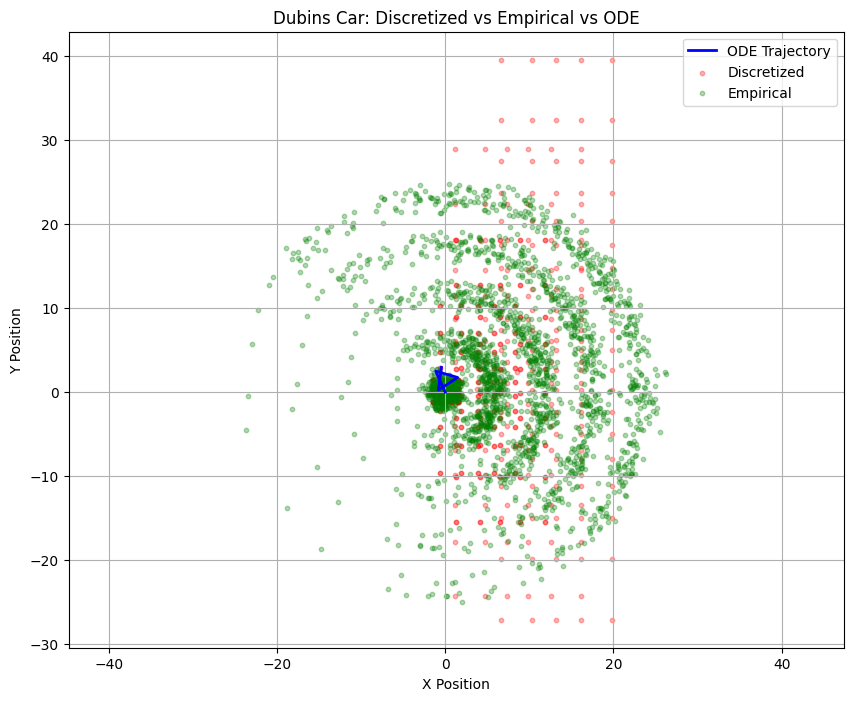

In [17]:

### 2D plot
# ODE reference
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x_traj, y_traj, label="ODE Trajectory", color="blue", linewidth=2)

# Discretized
for k, locs in enumerate(trajectories):
    x, y = locs[:, 0].numpy(), locs[:, 1].numpy()
    ax.scatter(x, y, color='red', alpha=0.3, s=10, label="Discretized" if k == 0 else None)

# Empirical
for k, locs in enumerate(empirical_trajectories):
    x, y = locs[:, 0].numpy(), locs[:, 1].numpy()
    ax.scatter(x, y, color='green', alpha=0.3, s=10, label="Empirical" if k == 0 else None)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Dubins Car: Discretized vs Empirical vs ODE")
ax.legend()
ax.grid()
plt.axis("equal")
plt.show()

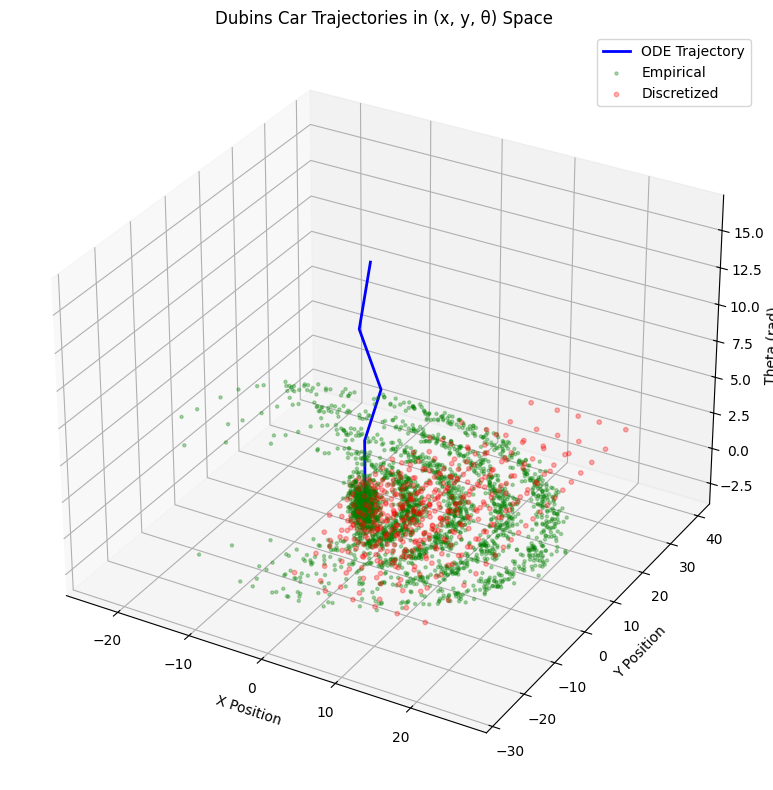

In [18]:
##### 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# ODE
ax.plot(solution.y[0], solution.y[1], solution.y[2], label="ODE Trajectory", color='blue', linewidth=2)

# Plot empirical particles
for k, locs in enumerate(empirical_trajectories):
    x, y, theta = locs[:, 0].numpy(), locs[:, 1].numpy(), locs[:, 2].numpy()
    ax.scatter(x, y, theta, color='green', alpha=0.3, s=5, label='Empirical' if k == 0 else None)

# Plot discretized particles
# same color
for k, locs in enumerate(trajectories):
    x, y, theta = locs[:, 0].numpy(), locs[:, 1].numpy(), locs[:, 2].numpy()
    ax.scatter(x, y, theta, color='red', alpha=0.3, s=10, label='Discretized' if k == 0 else None)

# # each time step diff colors
# cmap = cm.get_cmap('viridis', len(trajectories))
# 
# for k, locs in enumerate(trajectories):
#     x = locs[:, 0].numpy()
#     y = locs[:, 1].numpy()
#     theta = locs[:, 2].numpy()
# 
#     color = cmap(k / len(trajectories))  # Normalize k to [0,1] for the colormap
#     ax.scatter(x, y, theta, color=color, alpha=0.5, s=10)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_zlabel("Theta (rad)")
ax.set_title("Dubins Car Trajectories in (x, y, θ) Space")
ax.legend()
plt.tight_layout()
plt.show()